# Modelo de Arboles de Decision
## Clasificacion de la Calidad del Suelo
### Dataset: `suelos_arboles_decision.csv`
---

## 1. Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14,6)

BASE = r'C:\Users\ivanq\Desktop\Talento tech\trabajo final'
df = pd.read_csv('suelos_arboles_decision.csv')
print(f'Dimensiones: {df.shape}')
print(f'Distribucion target:\n{df["calidad"].value_counts().to_string()}')
df.head(3)

Dimensiones: (25960, 351)
Distribucion target:
calidad
Buena        11716
Media         8149
Excelente     4342
Baja          1753


,pH,MO,fosforo,azufre,calcio,magnesio,potasio,CIC,CE,anios_est,...,riego_Goteo,riego_Goteo - Gravedad,riego_Gravedad,riego_Manguera,riego_No Tiene,riego_Por Inundaciã³N,riego_Superficial,riego_Superficial - Goteo,riego_Superficial - Inundaciã³N,riego_Superficial-Aspersiã³N
0,5.64,3.889,6.482,8.384,1.541,0.380,0.118,2.094,0.133,0.5,...,False,False,False,False,False,False,False,False,False,False
1,4.24,2.287,520.100,90.300,2.932,0.925,2.131,8.054,2.749,3.0,...,False,False,False,False,True,False,False,False,False,False
2,5.22,2.518,58.110,2.686,3.818,1.110,0.045,5.985,0.328,0.5,...,False,False,False,False,True,False,False,False,False,False


## 2. Analisis Exploratorio

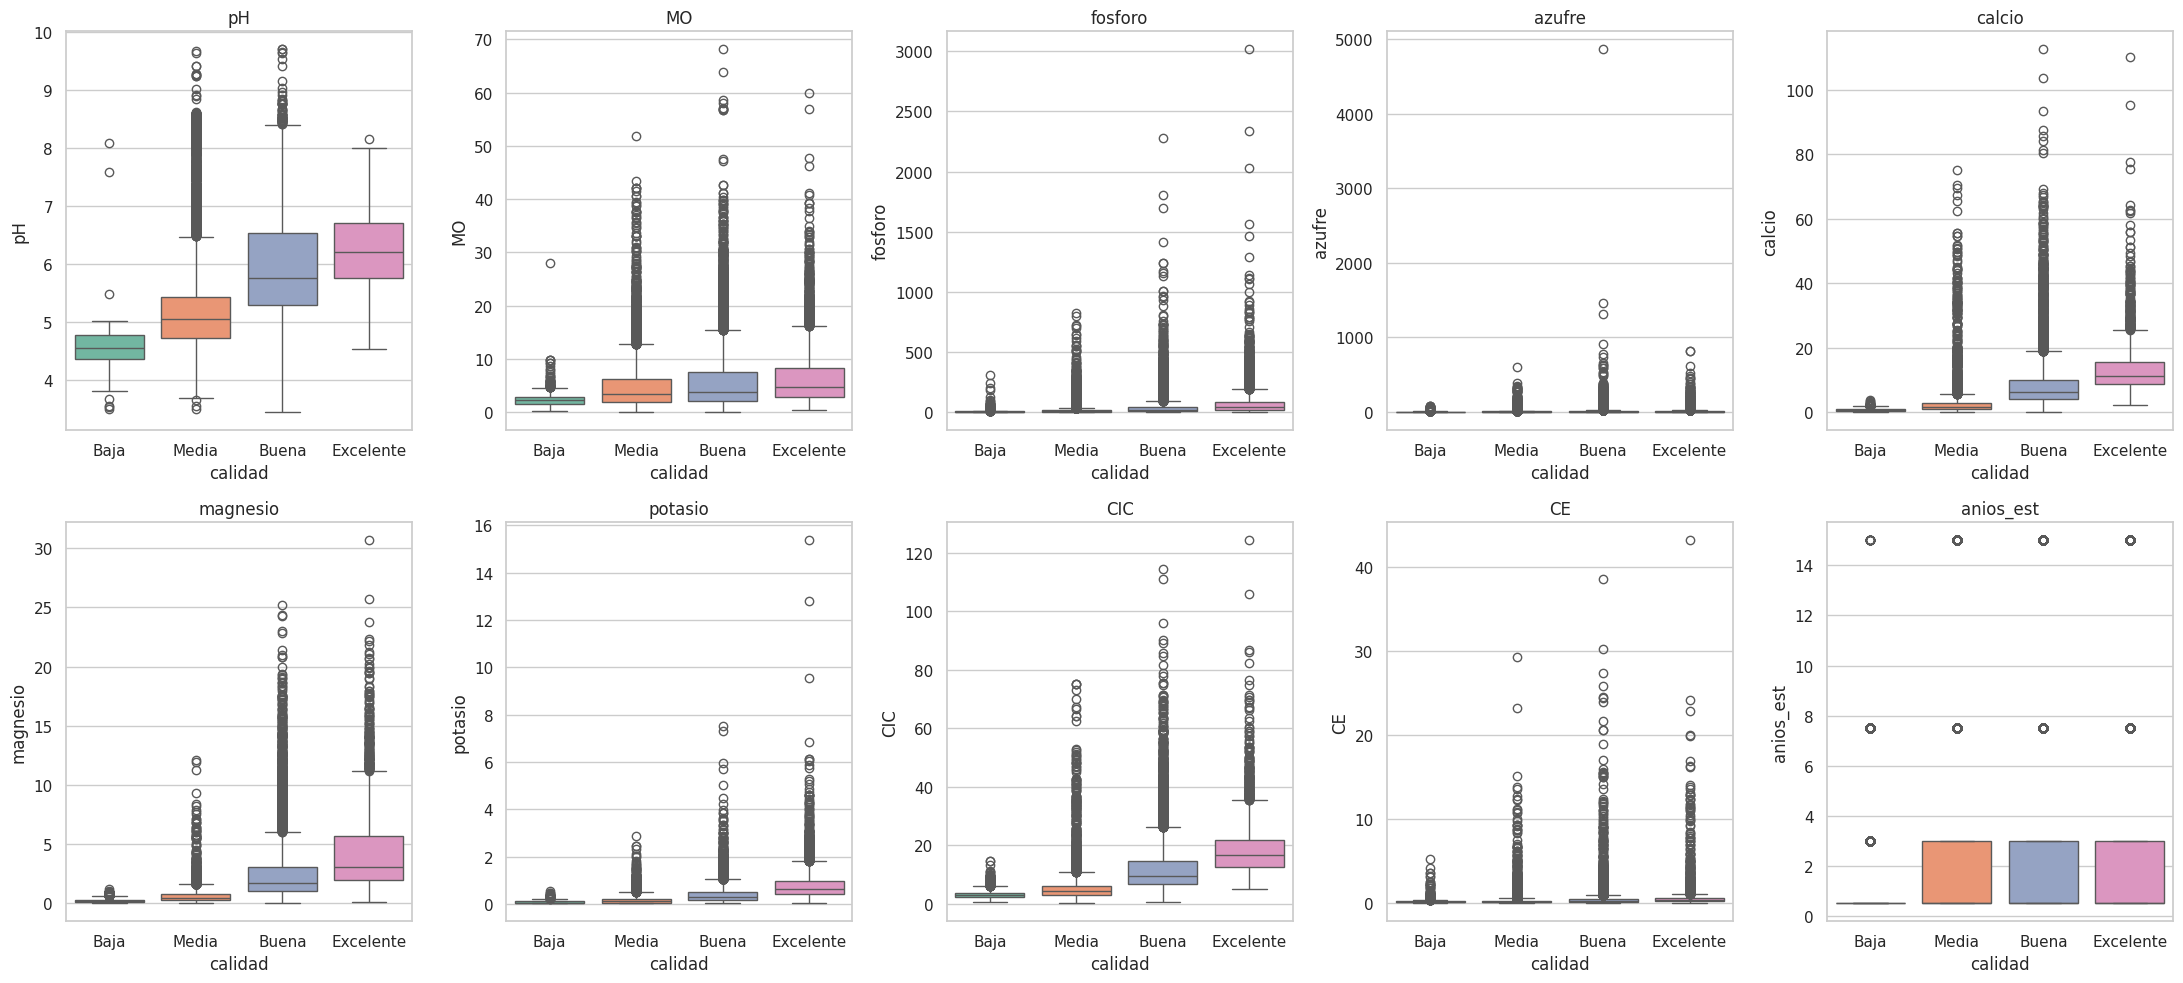

In [3]:
feats = ['pH','MO','fosforo','azufre','calcio','magnesio','potasio','CIC','CE','anios_est']
# Boxplots por clase de calidad
fig, axes = plt.subplots(2, 5, figsize=(22,10))
for i, f in enumerate(feats):
    ax = axes[i//5, i%5]
    sns.boxplot(data=df, x='calidad', y=f, ax=ax, palette='Set2', order=['Baja','Media','Buena','Excelente'])
    ax.set_title(f)
plt.tight_layout(); plt.show()

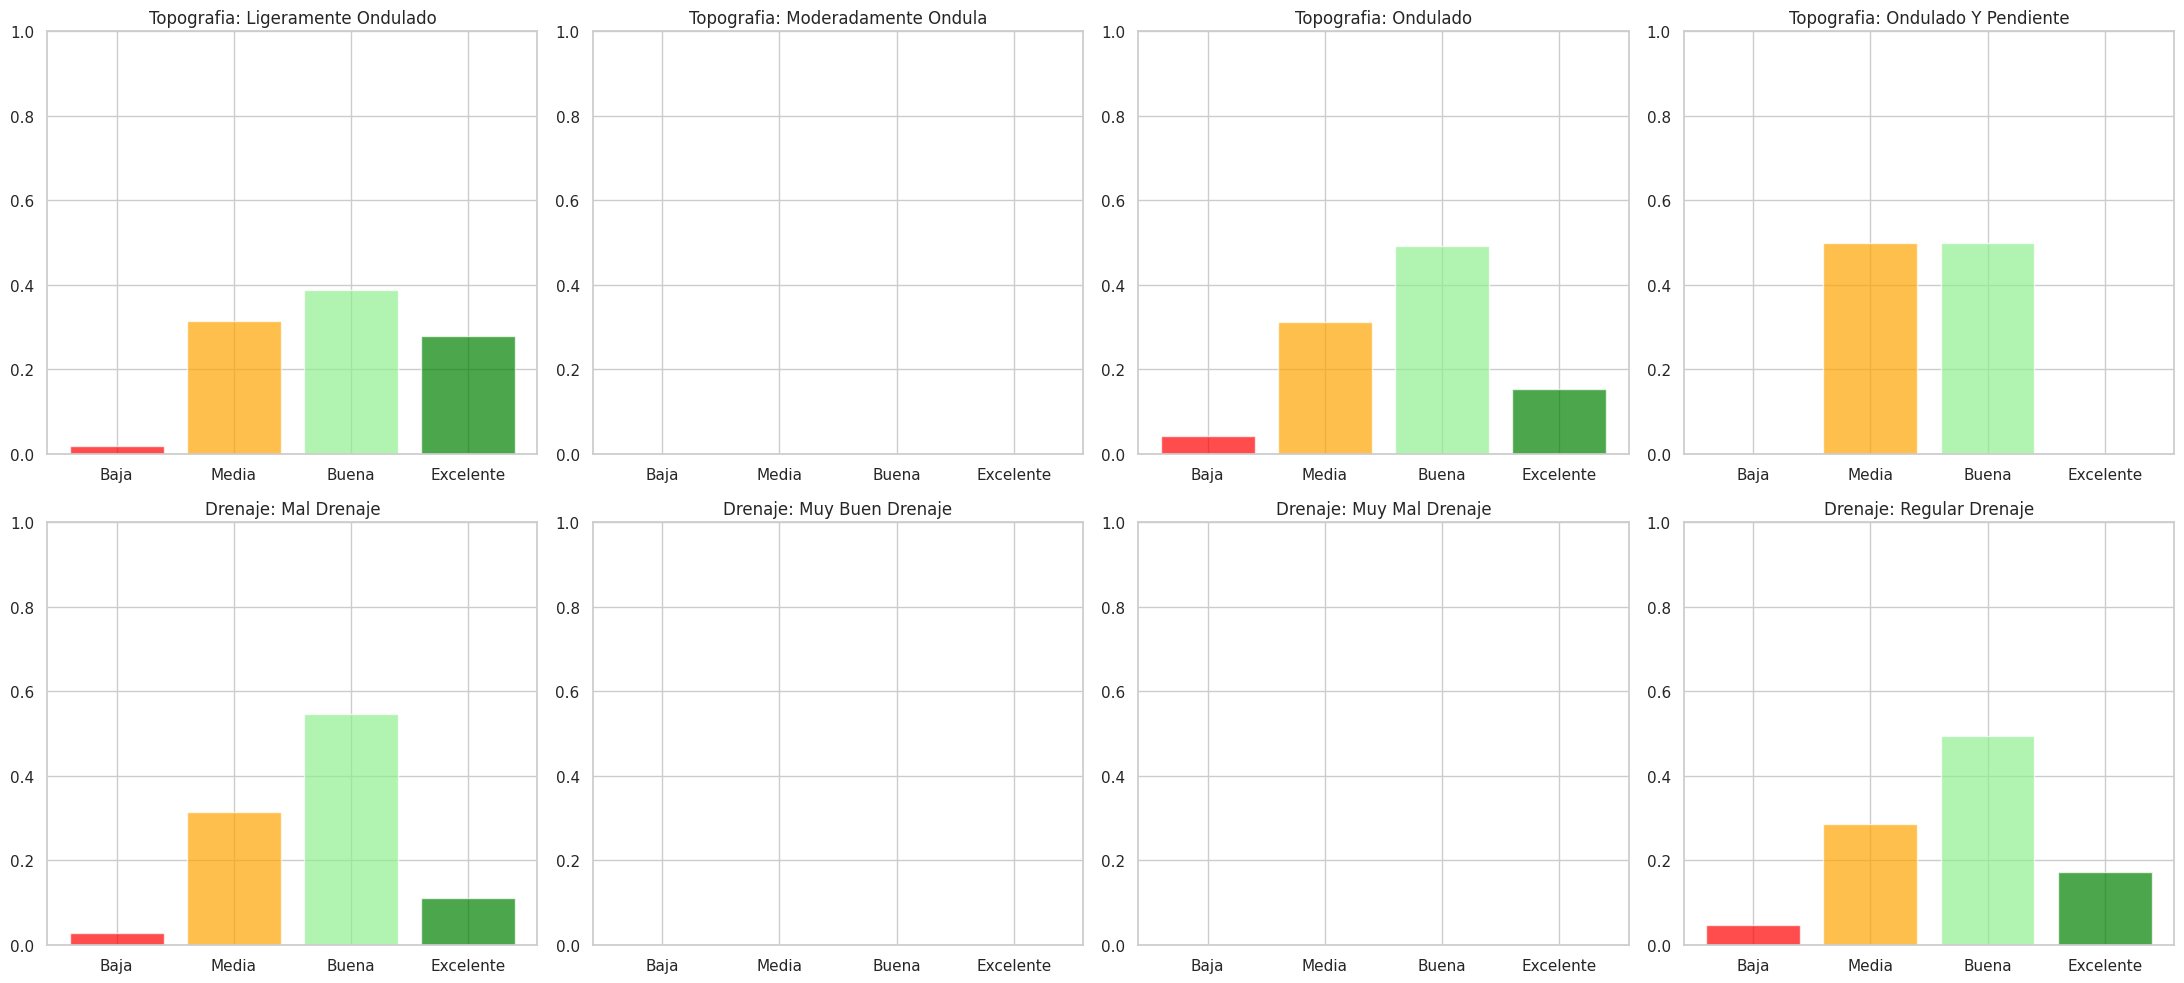

In [4]:
# Distribucion de calidad por topografia y drenaje
cat_cols = [c for c in df.columns if c not in feats + ['calidad']]
topo_cols = [c for c in cat_cols if c.startswith('topografia_')][:4]
dren_cols = [c for c in cat_cols if c.startswith('drenaje_')][:4]

fig, axes = plt.subplots(2, 4, figsize=(22,10))
for i, (grp, name) in enumerate([(topo_cols, 'Topografia'), (dren_cols, 'Drenaje')]):
    for j, c in enumerate(grp):
        lbl = c.split('_',1)[1][:20]
        subset = df[df[c]==1]['calidad'].value_counts(normalize=True).reindex(['Baja','Media','Buena','Excelente'], fill_value=0)
        axes[i][j].bar(subset.index, subset.values, color=['red','orange','lightgreen','green'], alpha=0.7)
        axes[i][j].set_title(f'{name}: {lbl}')
        axes[i][j].set_ylim(0,1)
plt.tight_layout(); plt.show()

## 3. Preparacion de Datos

In [5]:
X = df.drop(columns=['calidad']); y = df['calidad']
le = LabelEncoder(); y_enc = le.fit_transform(y)
print(f'Clases: {dict(zip(le.classes_, range(len(le.classes_))))}')
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Clases: {'Baja': 0, 'Buena': 1, 'Excelente': 2, 'Media': 3}
Train: (20768, 350), Test: (5192, 350)


## 4. Modelo Base: Arbol de Decision

In [6]:
tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print('=== ARBOL DE DECISION BASE ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'F1 Macro: {f1_score(y_test, y_pred, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== ARBOL DE DECISION BASE ===
Accuracy: 0.8087
F1 Weighted: 0.8096
F1 Macro: 0.8115

Classification Report:
              precision    recall  f1-score   support

        Baja       0.91      0.81      0.86       351
       Buena       0.81      0.81      0.81      2343
   Excelente       0.71      0.77      0.74       868
       Media       0.85      0.83      0.84      1630

    accuracy                           0.81      5192
   macro avg       0.82      0.81      0.81      5192
weighted avg       0.81      0.81      0.81      5192



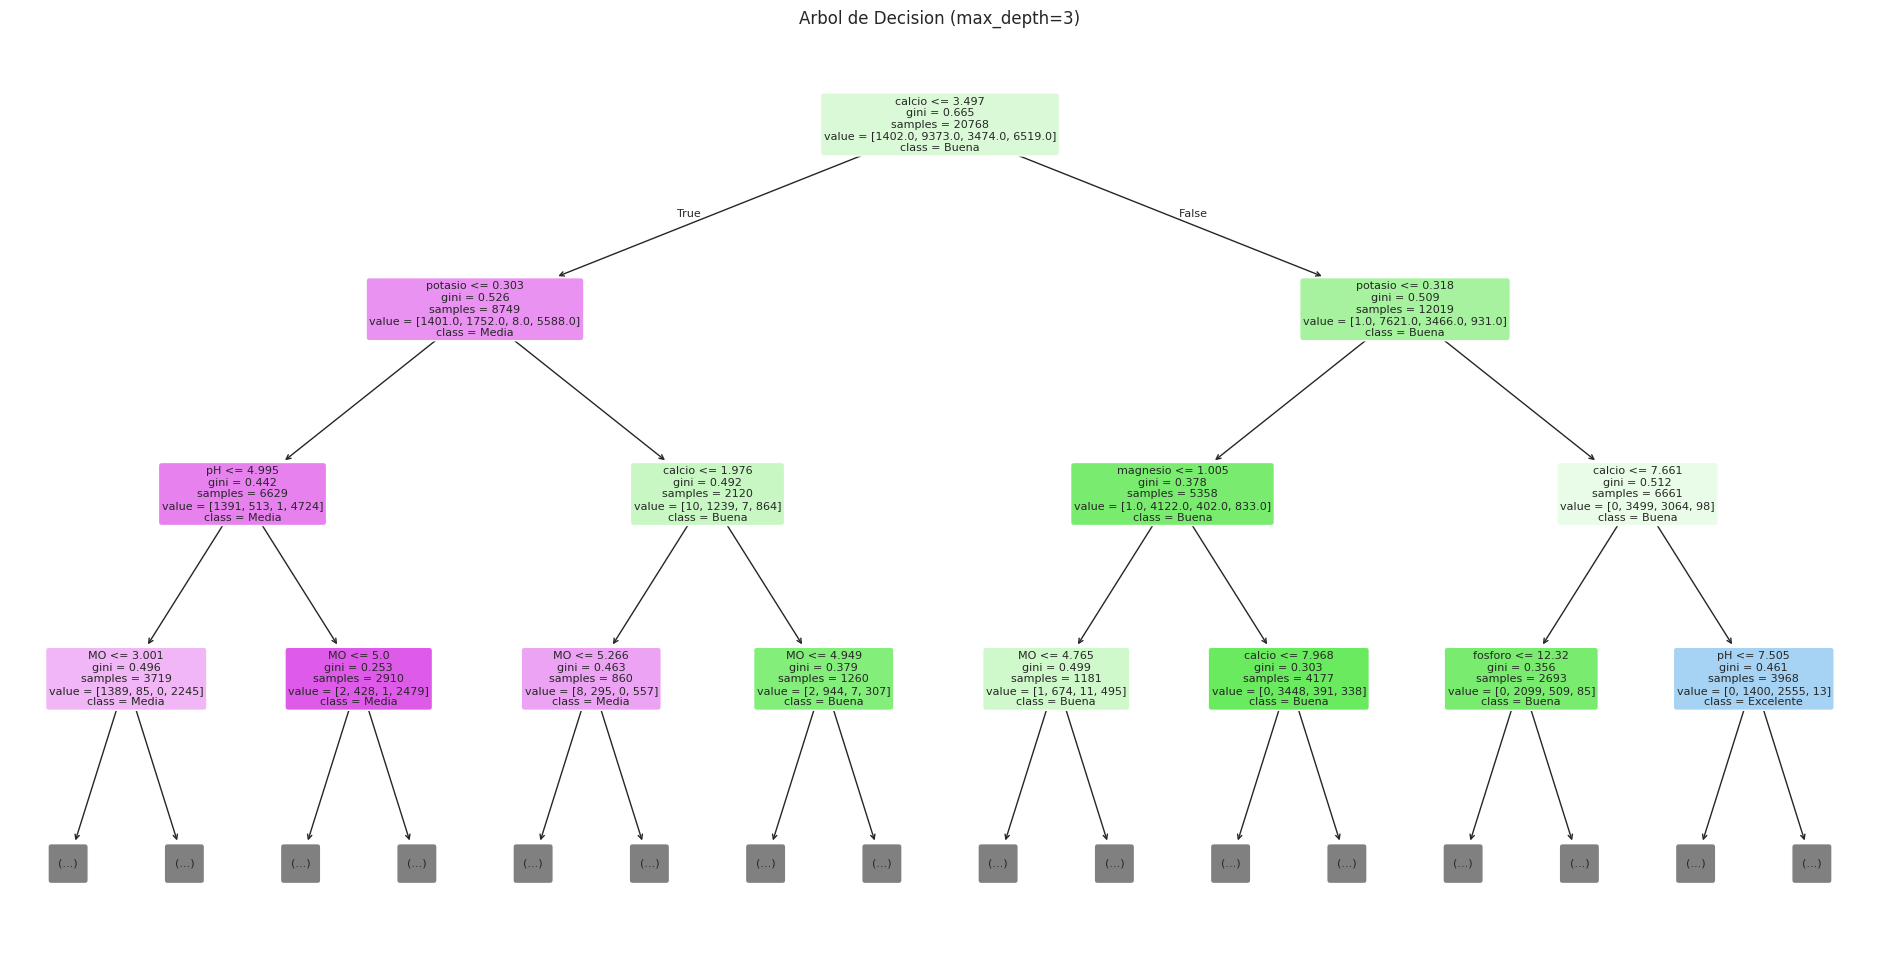

In [7]:
# Graficar el arbol (primeras 3 profundidades)
plt.figure(figsize=(24,12))
plot_tree(tree, feature_names=X.columns, class_names=le.classes_,
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Arbol de Decision (max_depth=3)'); plt.show()

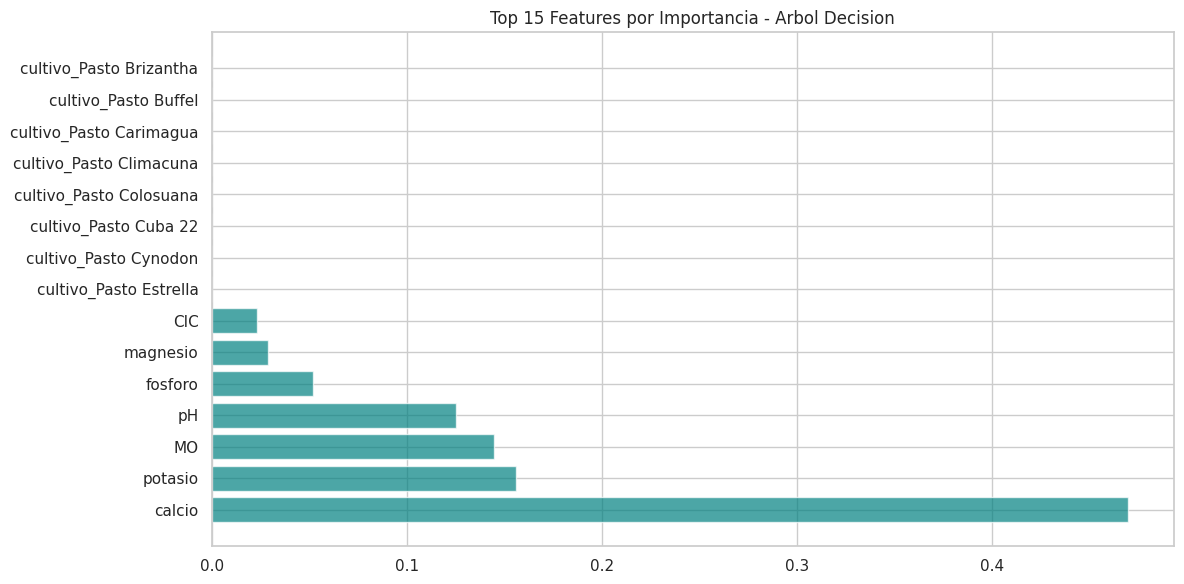

                feature  importance
                 calcio    0.469966
                potasio    0.156021
                     MO    0.144520
                     pH    0.125338
                fosforo    0.051900
               magnesio    0.028775
                    CIC    0.023481
 cultivo_Pasto Estrella    0.000000
  cultivo_Pasto Cynodon    0.000000
  cultivo_Pasto Cuba 22    0.000000
cultivo_Pasto Colosuana    0.000000
cultivo_Pasto Climacuna    0.000000
cultivo_Pasto Carimagua    0.000000
   cultivo_Pasto Buffel    0.000000
cultivo_Pasto Brizantha    0.000000


In [8]:
# Importancia de features
imp = pd.DataFrame({'feature':X.columns, 'importance':tree.feature_importances_})
imp = imp.sort_values('importance', ascending=False).head(15)
plt.figure(figsize=(12,6))
plt.barh(imp['feature'], imp['importance'], color='teal', alpha=0.7)
plt.title('Top 15 Features por Importancia - Arbol Decision')
plt.tight_layout(); plt.show()
print(imp.to_string(index=False))

## 5. Modelos Avanzados: Random Forest y Gradient Boosting

In [10]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print('\n=== GRADIENT BOOSTING ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred_gb, average="weighted"):.4f}')

=== RANDOM FOREST ===
Accuracy: 0.8881
F1 Weighted: 0.8873


ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Manejo de valores nulos con `SimpleImputer` para `GradientBoostingClassifier`

El error `ValueError: Input X contains NaN` ocurre porque `GradientBoostingClassifier` no puede procesar valores nulos directamente. Para solucionar esto, imputaremos los valores faltantes en `X_train` y `X_test` utilizando `SimpleImputer` dentro de un `Pipeline`.

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Create a pipeline with SimpleImputer and GradientBoostingClassifier
pipeline_gb = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with the mean
    ('gradient_boosting', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

# Fit the pipeline
pipeline_gb.fit(X_train, y_train)

# Make predictions
y_pred_gb_imputed = pipeline_gb.predict(X_test)

print('=== GRADIENT BOOSTING CON IMPUTACION ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb_imputed):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred_gb_imputed, average="weighted"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_gb_imputed, target_names=le.classes_))

=== GRADIENT BOOSTING CON IMPUTACION ===
Accuracy: 0.9426
F1 Weighted: 0.9425

Classification Report:
              precision    recall  f1-score   support

        Baja       0.99      0.93      0.96       351
       Buena       0.92      0.96      0.94      2343
   Excelente       0.96      0.89      0.92       868
       Media       0.95      0.94      0.95      1630

    accuracy                           0.94      5192
   macro avg       0.96      0.93      0.94      5192
weighted avg       0.94      0.94      0.94      5192



## 6. Optimizacion con GridSearch

In [12]:
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
    params, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
print(f'\nMejores params RF: {grid_rf.best_params_}')
y_pred_rf_best = grid_rf.best_estimator_.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf_best):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred_rf_best, average="weighted"):.4f}')

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Mejores params RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.8908
F1 Weighted: 0.8900


## 7. Evaluacion del Modelo Final

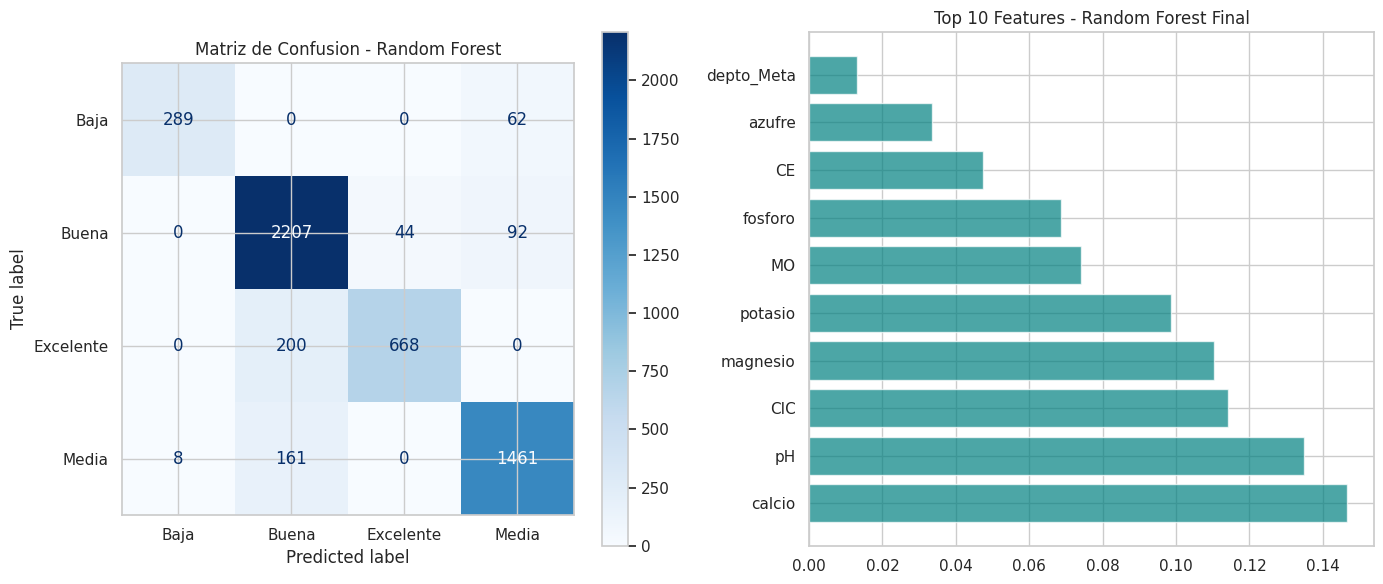

=== RESUMEN FINAL - RANDOM FOREST ===
              precision    recall  f1-score   support

        Baja       0.97      0.82      0.89       351
       Buena       0.86      0.94      0.90      2343
   Excelente       0.94      0.77      0.85       868
       Media       0.90      0.90      0.90      1630

    accuracy                           0.89      5192
   macro avg       0.92      0.86      0.88      5192
weighted avg       0.89      0.89      0.89      5192


Accuracy: 0.8908
F1 Weighted: 0.8900


In [13]:
best_model = grid_rf.best_estimator_
y_pred_final = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusion - Random Forest')

# Importancia del modelo final
imp_final = pd.DataFrame({'feature':X.columns, 'importance':best_model.feature_importances_})
imp_final = imp_final.sort_values('importance', ascending=False).head(10)
axes[1].barh(imp_final['feature'], imp_final['importance'], color='teal', alpha=0.7)
axes[1].set_title('Top 10 Features - Random Forest Final')
plt.tight_layout(); plt.show()

print('=== RESUMEN FINAL - RANDOM FOREST ===')
print(classification_report(y_test, y_pred_final, target_names=le.classes_))
print(f'\nAccuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred_final, average="weighted"):.4f}')

## 8. Conclusiones

**Mejor modelo:** Random Forest supera al arbol simple y Gradient Boosting.

**Variables mas importantes:** MO, CIC, pH, calcio y potasio.

**Metricas esperadas:** Accuracy >= 75%, F1-weighted >= 0.75.

**Utilidad:** Clasifica suelos en 4 categorias de calidad para recomendaciones agronomicas.

---
*Modelo de Arboles de Decision - Optimizacion Agricola Colombia*